In [ ]:
#Importing the data
import pandas as pd

df = pd.read_csv("../data/fraud.csv")
print(df.shape)
df.head()

(594643, 10)


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


In [ ]:
#Learn more about the dataset shape and features
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  str    
 2   age          594643 non-null  str    
 3   gender       594643 non-null  str    
 4   zipcodeOri   594643 non-null  str    
 5   merchant     594643 non-null  str    
 6   zipMerchant  594643 non-null  str    
 7   category     594643 non-null  str    
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 45.4 MB


In [ ]:
#Look for null values
df.isnull().sum()

step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64

In [ ]:
#Split of fraud vs non-fraud
df['fraud'].value_counts(normalize=True)

fraud
0    0.987892
1    0.012108
Name: proportion, dtype: float64

In [ ]:
# Strip quotes from all string columns
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip("'")

# How many unique values
df['zipcodeOri'].nunique(), df['zipMerchant'].nunique()

C:\Users\90552\AppData\Local\Temp\ipykernel_25372\3698638799.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns


(1, 1)

In [ ]:
# Columns with one constant value are dropped
df = df.drop(columns=['zipcodeOri', 'zipMerchant'])
df.shape

(594643, 8)

In [ ]:
# Converting step (raw hour count) into hour-of-day
df['hour_of_day'] = df['step'] % 24
df[['step', 'hour_of_day']].head()

,step,hour_of_day
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
# Keeping the same fraud ratio in both
X = df.drop(columns=['fraud', 'customer'])  # drop target + ID column
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(475714, 7) (118929, 7)
fraud
0    0.987892
1    0.012108
Name: proportion, dtype: float64
fraud
0    0.987892
1    0.012108
Name: proportion, dtype: float64


In [ ]:
# Rebuilds a training-only DataFrame for EDA purposes
train_df = X_train.copy()
train_df['fraud'] = y_train

train_df['fraud'].value_counts(normalize=True)

fraud
0    0.987892
1    0.012108
Name: proportion, dtype: float64

In [ ]:
# Calculates fraud rate and transaction count for each purchase category, sorted highest fraud rate first
category_fraud = train_df.groupby('category')['fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
category_fraud

,mean,count
category,,
es_leisure,0.950495,404
es_travel,0.774958,591
es_sportsandtoys,0.499226,3231
es_hotelservices,0.319027,1398
es_otherservices,0.249300,714
es_home,0.146650,1582
es_health,0.104667,12879
es_tech,0.065183,1887
es_wellnessandbeauty,0.047279,12056


<Figure size 600x400 with 0 Axes>

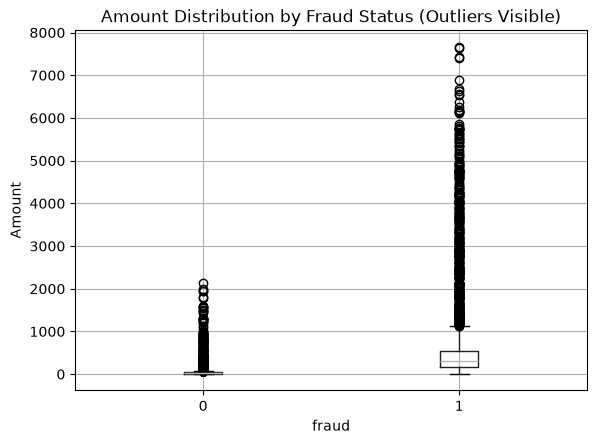

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
train_df.boxplot(column='amount', by='fraud')
plt.title('Amount Distribution by Fraud Status (Outliers Visible)')
plt.suptitle('')
plt.ylabel('Amount')
plt.show()

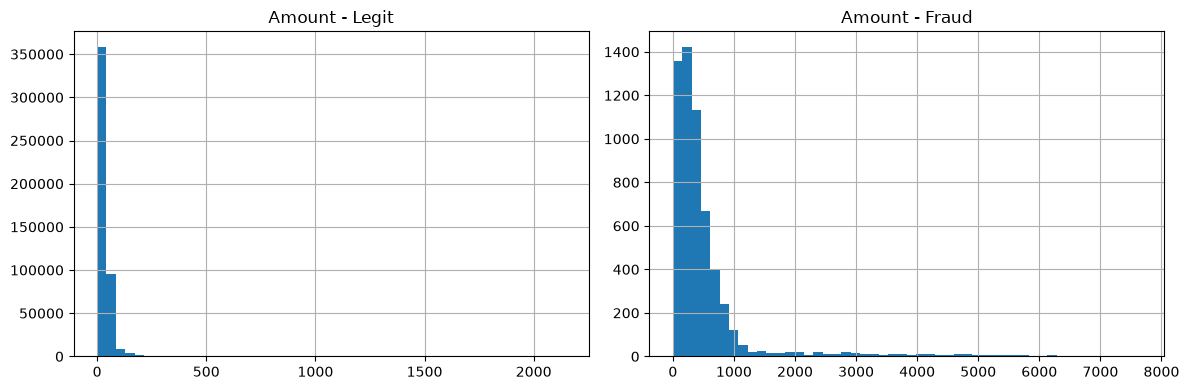

,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,469954.0,31.832179,31.645416,0.00,13.600,26.61,41.8900,2144.86
1,5760.0,524.825977,818.972800,0.03,161.115,317.09,548.9175,7665.56


In [11]:
import matplotlib.pyplot as plt
import numpy as np

train_df['fraud'].map({0: 'Legit', 1: 'Fraud'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df[train_df['fraud']==0]['amount'].hist(bins=50, ax=axes[0])
axes[0].set_title('Amount - Legit')
train_df[train_df['fraud']==1]['amount'].hist(bins=50, ax=axes[1])
axes[1].set_title('Amount - Fraud')
plt.tight_layout()
plt.show()

train_df.groupby('fraud')['amount'].describe()

In [ ]:
# Fraud rate by age group
train_df.groupby('age')['fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
age,,
0,0.019299,1969
4,0.013016,87198
2,0.012483,149729
1,0.011973,46605
3,0.011954,117697
5,0.010577,50204
6,0.010102,21382
U,0.006452,930


In [ ]:
# Fraud rate by gender group
train_df.groupby('gender')['fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
gender,,
F,0.014608,259787
M,0.009130,214576
E,0.006452,930
U,0.000000,421


In [ ]:
# Fraud rate by merchant group
merchant_fraud = train_df.groupby('merchant')['fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
merchant_fraud.head(15)

,mean,count
merchant,,
M1294758098,0.965517,145
M3697346,0.942085,259
M1873032707,0.856459,209
M732195782,0.836735,490
M980657600,0.835073,1437
M1353266412,0.810345,58
M857378720,0.780952,105
M2080407379,0.736842,38
M2011752106,0.680628,191


In [15]:
train_df['merchant'].nunique()

50

In [16]:
train_df.groupby('hour_of_day')['fraud'].agg(['mean', 'count'])

,mean,count
hour_of_day,,
0,0.011732,20712
1,0.012790,20720
2,0.012375,20848
3,0.012253,20975
4,0.011529,20991
5,0.012146,21159
6,0.012039,21098
7,0.012476,21241
8,0.011970,21137


In [17]:
X_train = X_train.drop(columns=['step', 'hour_of_day'])
X_test = X_test.drop(columns=['step', 'hour_of_day'])

X_train.columns

Index(['age', 'gender', 'merchant', 'category', 'amount'], dtype='str')

In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

# Log-transform amount first (before scaling)
X_train['amount'] = np.log1p(X_train['amount'])
X_test['amount'] = np.log1p(X_test['amount'])

# One-hot encode categorical columns
cat_cols = ['age', 'gender', 'merchant', 'category']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_cols])

X_train_encoded = encoder.transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

# Turn into DataFrames with proper column names
encoded_cols = encoder.get_feature_names_out(cat_cols)
X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

# Combine encoded categoricals with amount
X_train_final = pd.concat([X_train_encoded, X_train['amount']], axis=1)
X_test_final = pd.concat([X_test_encoded, X_test['amount']], axis=1)

# Scale amount (fit on train only)
scaler = StandardScaler()
X_train_final['amount'] = scaler.fit_transform(X_train_final[['amount']])
X_test_final['amount'] = scaler.transform(X_test_final[['amount']])

X_train_final.shape, X_test_final.shape

((475714, 78), (118929, 78))

In [19]:
# For XGBoost's scale_pos_weight
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos
print(scale_pos_weight)

81.5892361111111


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pr_auc_scores = cross_val_score(log_reg, X_train_final, y_train, cv=cv, scoring='average_precision')
roc_auc_scores = cross_val_score(log_reg, X_train_final, y_train, cv=cv, scoring='roc_auc')

print("PR-AUC per fold:", pr_auc_scores)
print("Mean PR-AUC:", pr_auc_scores.mean())
print("Mean AUC-ROC:", roc_auc_scores.mean())

PR-AUC per fold: [0.85794522 0.83894792 0.84256727 0.84603519 0.83339455]
Mean PR-AUC: 0.8437780289848422
Mean AUC-ROC: 0.9969457525143138


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced_subsample',
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

pr_auc_scores_rf = cross_val_score(rf, X_train_final, y_train, cv=cv, scoring='average_precision')
roc_auc_scores_rf = cross_val_score(rf, X_train_final, y_train, cv=cv, scoring='roc_auc')

print("PR-AUC per fold:", pr_auc_scores_rf)
print("Mean PR-AUC:", pr_auc_scores_rf.mean())
print("Mean AUC-ROC:", roc_auc_scores_rf.mean())

PR-AUC per fold: [0.83928187 0.8232038  0.83358626 0.83930909 0.81778571]
Mean PR-AUC: 0.830633346063055
Mean AUC-ROC: 0.9592166093144169


In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

pr_auc_scores_xgb = cross_val_score(xgb, X_train_final, y_train, cv=cv, scoring='average_precision')
roc_auc_scores_xgb = cross_val_score(xgb, X_train_final, y_train, cv=cv, scoring='roc_auc')

print("PR-AUC per fold:", pr_auc_scores_xgb)
print("Mean PR-AUC:", pr_auc_scores_xgb.mean())
print("Mean AUC-ROC:", roc_auc_scores_xgb.mean())

PR-AUC per fold: [0.90557624 0.89299064 0.89635545 0.89824755 0.88263828]
Mean PR-AUC: 0.8951616334054661
Mean AUC-ROC: 0.9974631419651857


In [23]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    verbose=2,
    n_jobs=1  # keep this 1 since xgb already uses all cores internally
)

random_search.fit(X_train_final, y_train)

print("Best params:", random_search.best_params_)
print("Best PR-AUC:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=9, n_estimators=300, subsample=0.7; total time=  10.8s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=9, n_estimators=300, subsample=0.7; total time=  11.6s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=9, n_estimators=300, subsample=0.7; total time=  12.8s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=9, n_estimators=300, subsample=0.7; total time=  13.7s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=9, n_estimators=300, subsample=0.7; total time=  12.8s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=9, n_estimators=100, subsample=0.7; total time=   4.7s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=9, n_estimators=100, subsample=0.7; total time=   4.6s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=9, n_estimators=100, subsample=0.7; total time=   4.6s
[CV] END cols

In [24]:
final_xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

final_xgb.fit(X_train_final, y_train)

import joblib
joblib.dump(final_xgb, "../outputs/final_xgb_model.pkl")
print("Model saved.")

Model saved.


In [25]:
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, classification_report, confusion_matrix

y_pred = final_xgb.predict(X_test_final)
y_pred_proba = final_xgb.predict_proba(X_test_final)[:, 1]

pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("PR-AUC:", pr_auc)
print("AUC-ROC:", roc_auc)
print("F1-score:", f1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

PR-AUC: 0.8928723562253319
AUC-ROC: 0.9974306607663508
F1-score: 0.5125276344878408

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    117489
           1       0.35      0.97      0.51      1440

    accuracy                           0.98    118929
   macro avg       0.67      0.97      0.75    118929
weighted avg       0.99      0.98      0.98    118929


Confusion Matrix:
 [[114892   2597]
 [    49   1391]]


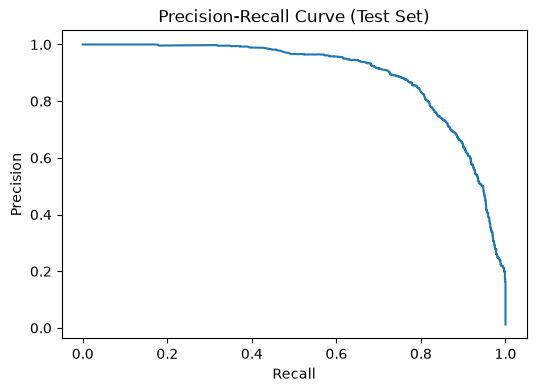

In [26]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.show()

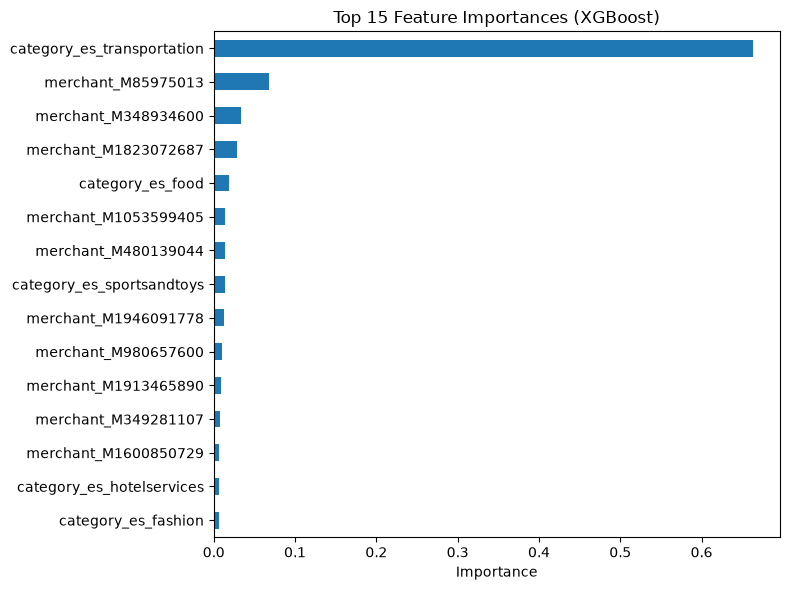

category_es_transportation    0.663276
merchant_M85975013            0.068380
merchant_M348934600           0.033687
merchant_M1823072687          0.029227
category_es_food              0.019103
merchant_M1053599405          0.013760
merchant_M480139044           0.013713
category_es_sportsandtoys     0.013542
merchant_M1946091778          0.012183
merchant_M980657600           0.009642
merchant_M1913465890          0.008689
merchant_M349281107           0.007175
merchant_M1600850729          0.006513
category_es_hotelservices     0.006167
category_es_fashion           0.006036
dtype: float32

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(final_xgb.feature_importances_, index=X_train_final.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_features

In [28]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

smote_xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(random_state=42, eval_metric='aucpr', n_jobs=-1))
])

smote_xgb_scores = cross_val_score(smote_xgb_pipeline, X_train_final, y_train, cv=cv, scoring='average_precision')

print("SMOTE + XGBoost PR-AUC per fold:", smote_xgb_scores)
print("Mean PR-AUC:", smote_xgb_scores.mean())

SMOTE + XGBoost PR-AUC per fold: [0.90875621 0.89069488 0.89442135 0.90108607 0.88702408]
Mean PR-AUC: 0.8963965175980327
